<a href="https://colab.research.google.com/drive/1jPe71IfxYrfBIY5RbKqtdq0jVHQQPz_r?authuser=0#scrollTo=dDAGa9oOCdE-" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Importamos las librerías

In [100]:
import tensorflow as tf
import tensorflow_datasets as tfds
import math
import numpy as np
import matplotlib.pyplot as plt
import logging
'''
import logging
Importa el módulo estándar de Python para gestionar mensajes de registro (logs).
Permite controlar qué tipo de mensajes se muestran: DEBUG, INFO, WARNING, ERROR, CRITICAL.
'''
logger= tf.get_logger()
'''
logger = tf.get_logger()
tf.get_logger() obtiene el logger interno de TensorFlow.
Este logger es responsable de mostrar mensajes durante la ejecución de
TensorFlow (por ejemplo, advertencias de compatibilidad, errores de GPU, etc.).
'''

logger.setLevel(logging.ERROR)
'''
logger.setLevel(logging.ERROR)
Configura el nivel mínimo de severidad que se mostrará.
En este caso, solo se mostrarán los errores (ERROR), y se ocultarán los
 mensajes de tipo INFO o WARNING.
'''
'''
¿Por qué usar esto?
TensorFlow suele imprimir muchos mensajes en consola, especialmente advertencias
 sobre compatibilidad, optimizaciones, etc. Esta configuración:

Reduce el ruido visual en notebooks o scripts.

Facilita la depuración al enfocarse solo en errores reales.

Es útil cuando ya conocés las advertencias y querés concentrarte en el resultado.
'''

'\n¿Por qué usar esto?\nTensorFlow suele imprimir muchos mensajes en consola, especialmente advertencias\n sobre compatibilidad, optimizaciones, etc. Esta configuración:\n\nReduce el ruido visual en notebooks o scripts.\n\nFacilita la depuración al enfocarse solo en errores reales.\n\nEs útil cuando ya conocés las advertencias y querés concentrarte en el resultado.\n'

In [101]:
dataset, metadata = tfds.load('mnist', as_supervised=True, with_info=True)

'''
tfds.load('mnist', ...)
Carga el conjunto de datos MNIST, que contiene 70,000 imágenes de dígitos
manuscritos (60,000 para entrenamiento y 10,000 para prueba).
Cada imagen es de 28×28 píxeles en escala de grises.

as_supervised=True
Devuelve los datos en formato (input, label), es decir, pares (imagen, dígito)
listos para entrenamiento supervisado.
Sin esta opción, los datos vendrían como diccionarios más complejos.

with_info=True
Devuelve también un objeto metadata con información adicional sobre el dataset:
Número de ejemplos
Descripción
Etiquetas
División entre entrenamiento y prueba
Formato de los datos
'''


"\ntfds.load('mnist', ...)\nCarga el conjunto de datos MNIST, que contiene 70,000 imágenes de dígitos \nmanuscritos (60,000 para entrenamiento y 10,000 para prueba).\nCada imagen es de 28×28 píxeles en escala de grises.\n\nas_supervised=True\nDevuelve los datos en formato (input, label), es decir, pares (imagen, dígito)\nlistos para entrenamiento supervisado.\nSin esta opción, los datos vendrían como diccionarios más complejos.\n\nwith_info=True\nDevuelve también un objeto metadata con información adicional sobre el dataset:\nNúmero de ejemplos\nDescripción\nEtiquetas\nDivisión entre entrenamiento y prueba\nFormato de los datos\n"

In [102]:
train_dataset, test_dataset = dataset['train'], dataset['test']
'''
dataset es un diccionario
Cuando usás tfds.load(...), el objeto que se guarda en dataset es de tipo dict, es decir, un diccionario de Python.

Los diccionarios almacenan pares clave–valor.

Para acceder a un valor, usás la clave entre corchetes: diccionario["clave"].

'''

'\ndataset es un diccionario\nCuando usás tfds.load(...), el objeto que se guarda en dataset es de tipo dict, es decir, un diccionario de Python.\n\nLos diccionarios almacenan pares clave–valor.\n\nPara acceder a un valor, usás la clave entre corchetes: diccionario["clave"].\n\n'

In [103]:
class_names=["Cero","Uno","Dos","Tres","Cuatro","Cinco","Seis","Siete","Ocho","Nueve"]
'''
Es una lista de 10 elementos, cada uno correspondiente a una clase del dataset MNIST.
En MNIST, las etiquetas son números enteros del 0 al 9.
Esta lista permite traducir esas etiquetas numéricas a nombres más interpretables.
'''

'\nEs una lista de 10 elementos, cada uno correspondiente a una clase del dataset MNIST.\nEn MNIST, las etiquetas son números enteros del 0 al 9.\nEsta lista permite traducir esas etiquetas numéricas a nombres más interpretables.\n'

In [104]:
num_train_examples = metadata.splits['train'].num_examples
num_test_examples = metadata.splits['test'].num_examples
'''
metadata
Es el objeto que contiene información descriptiva del dataset, devuelto por tfds.load(..., with_info=True).

metadata.splits
Es un diccionario que describe las divisiones del dataset (por ejemplo, "train", "test").

metadata.splits["train"]
Accede a la división de entrenamiento.

.num_examples
Devuelve el número total de ejemplos en esa división.
'''

'\nmetadata\nEs el objeto que contiene información descriptiva del dataset, devuelto por tfds.load(..., with_info=True).\n\nmetadata.splits\nEs un diccionario que describe las divisiones del dataset (por ejemplo, "train", "test").\n\nmetadata.splits["train"]\nAccede a la división de entrenamiento.\n\n.num_examples\nDevuelve el número total de ejemplos en esa división.\n'

##Normalización

In [105]:
def normalize(images, labels):
    images = tf.cast(images, tf.float32)
    images /= 255
    return images, labels



In [106]:
train_dataset = train_dataset.map(normalize)
test_dataset = test_dataset.map(normalize)
'''
train_dataset.map(normalizacion)
Aplica la función normalizacion(imagenes, etiquetas) a cada par (imagen, etiqueta) del dataset.
Es una operación perezosa (lazy): no transforma los datos inmediatamente, sino que define cómo deben transformarse cuando se usen.
Es altamente eficiente y compatible con el pipeline de entrenamiento.
Podés imaginar .map(normalizacion) como aplicar un filtro artístico a cada
imagen del dataset, suavizando sus tonos para que la red neuronal pueda “pintar”
con precisión sus predicciones.

.map() en TensorFlow (y también en Python en general) es una herramienta
 poderosa para aplicar transformaciones a cada elemento de una secuencia
de datos, como un dataset. En el contexto de tf.data.Dataset, .map() permite
procesar cada ejemplo de forma eficiente y paralela.
'''

'\ntrain_dataset.map(normalizacion)\nAplica la función normalizacion(imagenes, etiquetas) a cada par (imagen, etiqueta) del dataset.\nEs una operación perezosa (lazy): no transforma los datos inmediatamente, sino que define cómo deben transformarse cuando se usen.\nEs altamente eficiente y compatible con el pipeline de entrenamiento.\nPodés imaginar .map(normalizacion) como aplicar un filtro artístico a cada \nimagen del dataset, suavizando sus tonos para que la red neuronal pueda “pintar”\ncon precisión sus predicciones.\n\n.map() en TensorFlow (y también en Python en general) es una herramienta\n poderosa para aplicar transformaciones a cada elemento de una secuencia\nde datos, como un dataset. En el contexto de tf.data.Dataset, .map() permite \nprocesar cada ejemplo de forma eficiente y paralela.\n'

##Estructura de la red

In [107]:
'''
red neuronal secuencial en Keras
'''
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(64, activation=tf.nn.relu),
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])
'''
¿Qué es tf.keras.Sequential?
Es una forma de construir redes capa por capa, donde cada capa tiene una única
entrada y una única salida. Es ideal para arquitecturas simples y lineales como esta.

Flatten(input_shape=(28,28,1))
Convierte cada imagen de 28×28 píxeles en un vector de 784 elementos.
Es como desenrollar la imagen para que pueda entrar en una capa densa.
input_shape=(28,28,1) indica que las imágenes tienen un canal (escala de grises).

Dense(64, activation=tf.nn.relu)
Capa totalmente conectada con 64 neuronas.
Usa la función de activación ReLU (Rectified Linear Unit), que introduce no linealidad.
Esta capa aprende representaciones intermedias de los dígitos.

Dense(10, activation=tf.nn.softmax)
Capa de salida con 10 neuronas, una por cada clase (dígito del 0 al 9).
softmax convierte los valores en probabilidades que suman 1.
El índice con mayor probabilidad será la predicción del modelo.
'''

'\n¿Qué es tf.keras.Sequential?\nEs una forma de construir redes capa por capa, donde cada capa tiene una única\nentrada y una única salida. Es ideal para arquitecturas simples y lineales como esta.\n\nFlatten(input_shape=(28,28,1))\nConvierte cada imagen de 28×28 píxeles en un vector de 784 elementos.\nEs como desenrollar la imagen para que pueda entrar en una capa densa.\ninput_shape=(28,28,1) indica que las imágenes tienen un canal (escala de grises).\n\nDense(64, activation=tf.nn.relu)\nCapa totalmente conectada con 64 neuronas.\nUsa la función de activación ReLU (Rectified Linear Unit), que introduce no linealidad.\nEsta capa aprende representaciones intermedias de los dígitos.\n\nDense(10, activation=tf.nn.softmax)\nCapa de salida con 10 neuronas, una por cada clase (dígito del 0 al 9).\nsoftmax convierte los valores en probabilidades que suman 1.\nEl índice con mayor probabilidad será la predicción del modelo.\n'

In [108]:
model.compile(
	optimizer='adam',
	loss='sparse_categorical_crossentropy',
	metrics=['accuracy']
)
'''
optimizer='adam'
Usa el optimizador Adam, que combina lo mejor de SGD y RMSprop.
Ajusta los pesos del modelo para minimizar la pérdida.
Es eficiente, robusto y muy usado en tareas de clasificación como MNIST.

loss='sparse_categorical_crossentropy'
Función de pérdida para clasificación multiclase con etiquetas enteras (no one-hot).
Calcula cuán lejos están las predicciones del modelo respecto a las etiquetas verdaderas.
Ideal para datasets como MNIST, donde las etiquetas son números del 0 al 9.

metrics=['accuracy']
Mide la precisión del modelo: qué porcentaje de predicciones fueron correctas.

imagina compile() como afinar un instrumento antes de tocar: elegís el tipo de
cuerdas (optimizer), el tono que querés lograr (loss), y cómo vas a medir si
estás tocando bien (accuracy).

'''


"\noptimizer='adam'\nUsa el optimizador Adam, que combina lo mejor de SGD y RMSprop.\nAjusta los pesos del modelo para minimizar la pérdida.\nEs eficiente, robusto y muy usado en tareas de clasificación como MNIST.\n\nloss='sparse_categorical_crossentropy'\nFunción de pérdida para clasificación multiclase con etiquetas enteras (no one-hot).\nCalcula cuán lejos están las predicciones del modelo respecto a las etiquetas verdaderas.\nIdeal para datasets como MNIST, donde las etiquetas son números del 0 al 9.\n\nmetrics=['accuracy']\nMide la precisión del modelo: qué porcentaje de predicciones fueron correctas.\n\nimagina compile() como afinar un instrumento antes de tocar: elegís el tipo de\ncuerdas (optimizer), el tono que querés lograr (loss), y cómo vas a medir si\nestás tocando bien (accuracy).\n\n"

In [109]:
BATCHSIZE = 32
train_dataset = train_dataset.repeat().shuffle(num_train_examples).batch(BATCHSIZE)
test_dataset = test_dataset.batch(BATCHSIZE)


'''
Esa línea configura el pipeline de datos para entrenamiento y prueba, usando
las transformaciones de tf.data.Dataset.

BATCHSIZE = 32
Define el tamaño de lote: cuántos ejemplos se procesan juntos en cada paso
de entrenamiento.
Un tamaño de 32 es común y balancea eficiencia computacional con estabilidad
de gradient

train_dataset.repeat()
Hace que el conjunto de entrenamiento se repita infinitamente.
Es útil cuando usás model.fit() con steps_per_epoch, porque evita que
se agoten los datos.

.shuffle(num_train_examples)
Mezcla aleatoriamente los ejemplos en cada época.
num_train_examples asegura que se mezclen todos los datos.
Ayuda a evitar que el modelo aprenda patrones espurios por el orden de los datos.

.batch(BATCHSIZE)
Agrupa los datos en lotes de 32 ejemplos.
Cada lote se procesa como una unidad durante el entrenamiento.

test_dataset.batch(BATCHSIZE)
No se repite ni se mezcla, porque el conjunto de prueba debe mantenerse
constante para evaluar el rendimiento del modelo.

imagina este pipeline como una máquina de entrenamiento artístico:
repeat() mantiene la cinta corriendo sin fin.
shuffle() mezcla los lienzos para que el modelo no se acostumbre a un orden.
batch() agrupa las obras en exposiciones de 32 piezas para que el modelo las
analice en conjunto.
'''



'\nEsa línea configura el pipeline de datos para entrenamiento y prueba, usando \nlas transformaciones de tf.data.Dataset. \n\nBATCHSIZE = 32\nDefine el tamaño de lote: cuántos ejemplos se procesan juntos en cada paso \nde entrenamiento.\nUn tamaño de 32 es común y balancea eficiencia computacional con estabilidad\nde gradient\n\ntrain_dataset.repeat()\nHace que el conjunto de entrenamiento se repita infinitamente.\nEs útil cuando usás model.fit() con steps_per_epoch, porque evita que \nse agoten los datos.\n\n.shuffle(num_train_examples)\nMezcla aleatoriamente los ejemplos en cada época.\nnum_train_examples asegura que se mezclen todos los datos.\nAyuda a evitar que el modelo aprenda patrones espurios por el orden de los datos.\n\n.batch(BATCHSIZE)\nAgrupa los datos en lotes de 32 ejemplos.\nCada lote se procesa como una unidad durante el entrenamiento.\n\ntest_dataset.batch(BATCHSIZE)\nNo se repite ni se mezcla, porque el conjunto de prueba debe mantenerse \nconstante para evaluar el

##Entrenamiento

In [110]:
for imagen, etiqueta in train_dataset.take(1):
    print(imagen.shape)

(32, 28, 28, 1)


In [111]:
model.fit(
	train_dataset, epochs=5,
	steps_per_epoch=math.ceil(num_train_examples/BATCHSIZE) #No sera necesario pronto
)
'''
model.fit(...)
Es el método que entrena el modelo usando los datos que le pasás.
Ajusta los pesos internos para minimizar la función de pérdida.

train_datatset
Es el conjunto de entrenamiento ya preparado con .repeat().shuffle().batch().
Contiene ejemplos normalizados y listos para ser procesados en lotes.

epochs=5
El modelo verá todo el conjunto de entrenamiento 5 veces.
Cada pasada completa se llama una “época”.

steps_per_epoch=math.ceil(num_train_examples / BATCHSIZE)
Define cuántos lotes se procesan por época.

num_train_examples es la cantidad total de ejemplos (por ejemplo, 60,000).

BATCHSIZE es el tamaño de cada lote (por ejemplo, 32).

math.ceil(...) redondea hacia arriba para cubrir todos los ejemplos,
incluso si el último lote es incompleto.

¿Por qué es importante steps_per_epoch?
Porque train_dataset está configurado con .repeat(), lo que lo hace infinito.
Sin steps_per_epoch, el entrenamiento no sabría cuándo terminar una época.
Este parámetro le dice al modelo: “Después de 1875 lotes, considerá que
completaste una época”.

Podés imaginar el entrenamiento como una serie de exposiciones artísticas.
Cada lote es una sala con 32 obras, y después de recorrer 1875 salas,
el modelo completa una vuelta por toda la galería. Repite ese recorrido 5
veces para afinar su percepción.
'''

Epoch 1/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 6ms/step - accuracy: 0.8620 - loss: 0.4807
Epoch 2/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9596 - loss: 0.1351
Epoch 3/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9726 - loss: 0.0903
Epoch 4/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9777 - loss: 0.0740
Epoch 5/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9816 - loss: 0.0584
Epoch 6/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9832 - loss: 0.0551
Epoch 7/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9876 - loss: 0.0413
Epoch 8/8
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9877 - loss: 0.0368


'\nmodel.fit(...)\nEs el método que entrena el modelo usando los datos que le pasás.\nAjusta los pesos internos para minimizar la función de pérdida.\n\ntrain_datatset\nEs el conjunto de entrenamiento ya preparado con .repeat().shuffle().batch().\nContiene ejemplos normalizados y listos para ser procesados en lotes.\n\nepochs=5\nEl modelo verá todo el conjunto de entrenamiento 5 veces.\nCada pasada completa se llama una “época”.\n\nsteps_per_epoch=math.ceil(num_train_examples / BATCHSIZE)\nDefine cuántos lotes se procesan por época.\n\nnum_train_examples es la cantidad total de ejemplos (por ejemplo, 60,000).\n\nBATCHSIZE es el tamaño de cada lote (por ejemplo, 32).\n\nmath.ceil(...) redondea hacia arriba para cubrir todos los ejemplos,\nincluso si el último lote es incompleto.\n\n¿Por qué es importante steps_per_epoch?\nPorque train_dataset está configurado con .repeat(), lo que lo hace infinito.\nSin steps_per_epoch, el entrenamiento no sabría cuándo terminar una época.\nEste parámet

##Evaluar el modelo

In [122]:
test_loss, test_accuracy = model.evaluate(
	test_dataset, steps=math.ceil(num_test_examples/32)
)
'''
test_dataset
Es el conjunto de prueba, ya preparado con .batch(32).
No se repite ni se mezcla, para mantener la evaluación objetiva y constante.

steps=math.ceil(num_test_examples / 32)
Indica cuántos lotes se deben procesar para cubrir todo el conjunto de prueba.

model.evaluate(...)
Calcula la pérdida (test_loss) y la precisión (test_accuracy) del modelo sobre
los datos de prueba.
No ajusta pesos, solo mide rendimiento.
'''

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9720 - loss: 0.0930


'\ntest_dataset\nEs el conjunto de prueba, ya preparado con .batch(32).\nNo se repite ni se mezcla, para mantener la evaluación objetiva y constante.\n\nsteps=math.ceil(num_test_examples / 32)\nIndica cuántos lotes se deben procesar para cubrir todo el conjunto de prueba.\n\nmodel.evaluate(...)\nCalcula la pérdida (test_loss) y la precisión (test_accuracy) del modelo sobre\nlos datos de prueba.\nNo ajusta pesos, solo mide rendimiento.\n'

In [123]:
print("Resultado en las pruebas: ", test_accuracy)

Resultado en las pruebas:  0.9722999930381775


In [124]:
for test_images, test_labels in test_dataset.take(1):
	test_images = test_images.numpy()
	test_labels = test_labels.numpy()
	predictions = model.predict(test_images)

  '''
test_dataset.take(1)
Toma un solo lote del conjunto de prueba.
Si el batch size es 32, entonces test_images.shape = (32, 28, 28, 1).

.numpy()
Convierte los tensores de TensorFlow a arrays de NumPy.
Esto es necesario para visualización con matplotlib y manipulación con np.argmax, etc.

model.predict(test_images)
Genera las predicciones del modelo para ese lote.
Devuelve un array de forma (32, 10) si tenés 10 clases.
Cada fila es un vector de probabilidades para una imagen.
  '''


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


In [125]:
def plot_image(i, predictions_array, true_labels, images):
	predictions_array, true_label, img = predictions_array[i], true_labels[i], images[i]
	plt.grid(False)
	plt.xticks([])
	plt.yticks([])

	plt.imshow(img[...,0], cmap=plt.cm.binary)

	predicted_label = np.argmax(predictions_array)
	if predicted_label == true_label:
		color = 'blue'
	else:
		color = 'red'

	plt.xlabel("Prediccion: {}".format(class_names[predicted_label]), color=color)

 '''
 Selecciona el ejemplo número i:
Toma la imagen, su etiqueta real y la predicción del modelo.
Prepara el gráfico:
Quita la grilla y los números de los ejes.
Muestra la imagen en blanco y negro.
Calcula la clase predicha:
Usa np.argmax para encontrar la clase con mayor probabilidad.
Compara con la etiqueta real:
Si acertó, usa color azul.
Si falló, usa color rojo.
Escribe la predicción debajo de la imagen:
Muestra el nombre de la clase predicha en el color correspondiente.
 '''

In [126]:
def plot_value_array(i, predictions_array, true_label):
	predictions_array, true_label = predictions_array[i], true_label[i]
  '''
  predictions_array[i]: vector con 10 probabilidades (una por clase).
  true_label[i]: clase verdadera (número entre 0 y 9).
  '''
	plt.grid(False)
	plt.xticks([])
	plt.yticks([])
  '''
  Elimina grilla y marcas de eje para una visualización limpia.
  '''
	thisplot = plt.bar(range(10), predictions_array, color="#888888")
	plt.ylim([0,1])
  '''
  Crea 10 barras grises, una por clase.
  Altura = probabilidad asignada por el modelo.
  '''
	predicted_label = np.argmax(predictions_array)

	thisplot[predicted_label].set_color('red')
	thisplot[true_label].set_color('blue')
  '''
  La barra roja es la clase que el modelo predijo.
  La barra azul es la clase verdadera.
  '''

'''
Entrada:
i: índice de la imagen que querés analizar.
predictions_array: lista de vectores de probabilidad (uno por imagen).
true_label: lista de etiquetas verdaderas.
Visualización:
Muestra un gráfico de barras con 10 columnas (una por clase).
Cada barra representa la probabilidad que el modelo asignó a esa clase.
Colores:
La barra roja indica la clase que el modelo predijo.
La barra azul indica la clase verdadera.
'''


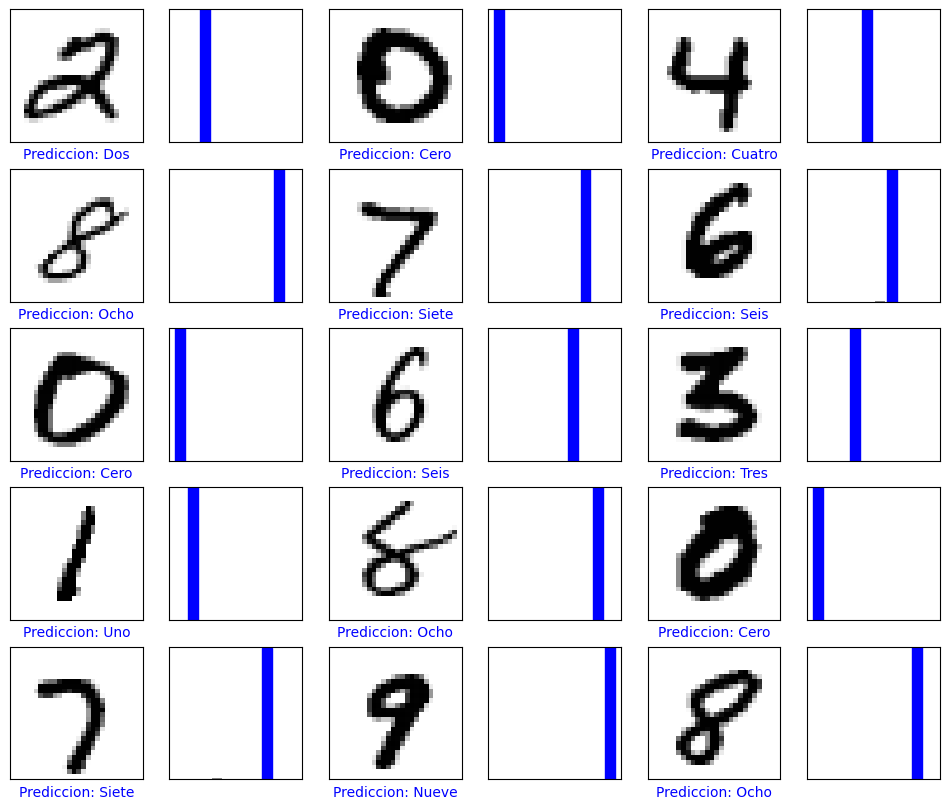

In [127]:
numrows=5
numcols=3
numimages = numrows*numcols
'''
Va a mostrar 15 imágenes (5 filas × 3 columnas).
Cada imagen ocupará dos subgráficos: uno para la imagen, otro para la barra
de probabilidades.
'''
plt.figure(figsize=(2*2*numcols, 2*numrows))
'''
Define el tamaño total de la figura.
Multiplica por 2 para que haya espacio suficiente para cada imagen y su gráfico de barras.
'''
for i in range(numimages):
  '''
  Recorre los primeros 15 ejemplos del lote.
  '''
	plt.subplot(numrows, 2*numcols, 2*i+1)
	plot_image(i, predictions, test_labels, test_images)
  '''
  Crea un subgráfico en la posición correspondiente.
  Llama a plot_image(...) para mostrar la imagen y la clase predicha (en azul si acierta, rojo si falla).
  '''
	plt.subplot(numrows, 2*numcols, 2*i+2)
	plot_value_array(i, predictions, test_labels)
  '''
  Crea otro subgráfico al lado de la imagen.
  Muestra las probabilidades que el modelo asignó a cada clase.
  La barra azul es la clase real, la roja es la predicha.
  '''

plt.show()
'''
Renderiza la figura completa con 15 pares de imagen + gráfico de barras.
'''